# Первая лабораторная работа на тему ARIMA.

Данные в файле  M3_152_0.csv
Данные по годам.
Информация о данных отсутствует.

**Задача.**
Подобрать параметры модели ARIMA,
описать процедуру подбора в комментариях,
построить прогноз на 4 года вперед.



In [296]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
import random

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [297]:
df1 = pd.read_csv('/content/M3_152_0.csv', sep=',', header=None, index_col=0)
len(df1)

38

In [298]:
df1.tail()

,1
0,
33,5861.5
34,6346.7
35,6606.1
36,6762.7
37,7507.4


<Axes: xlabel='0'>

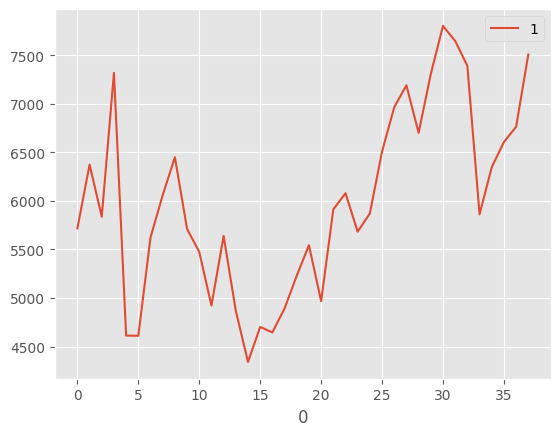

In [299]:
df1.plot()

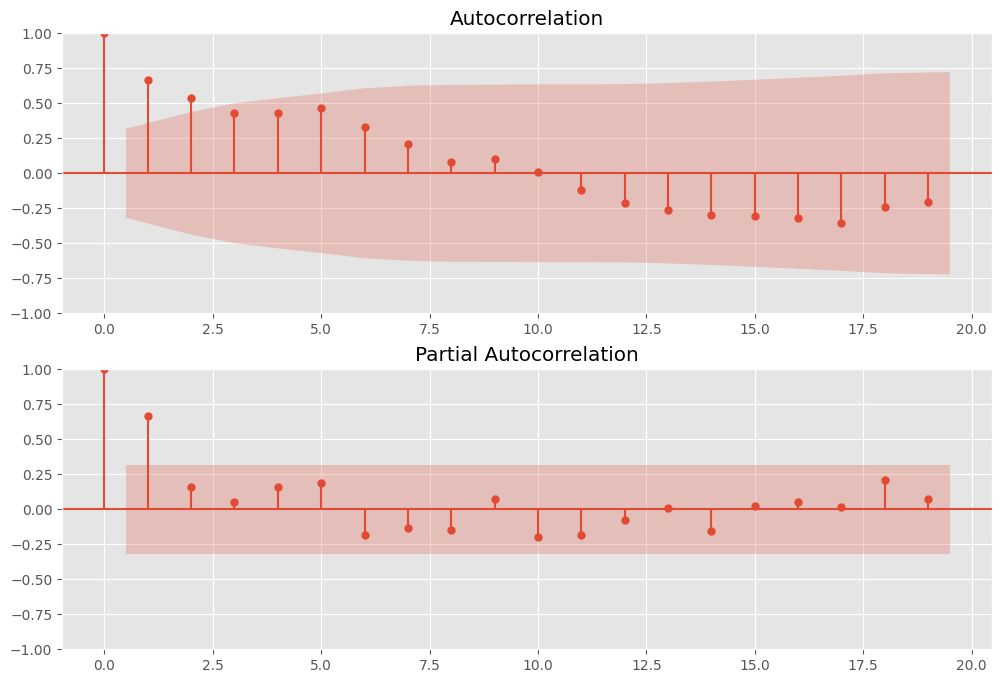

In [300]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df1, lags=19, ax=plt.gca())
plt.subplot(212)

plot_pacf(df1, method='ywmle', lags=19, ax=plt.gca())
plt.show()

Если смотреть на графики, то получается, что автокорреляция экспоненциально убывает, а частичная имеет выброс на лаге 1.

Следовательно, параметры для модели ARIMA должны быть следующие: (1, 0, 0)  

In [301]:
model = ARIMA(df1, order=(1,0,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                   38
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -302.554
Date:                Wed, 13 May 2026   AIC                            611.107
Time:                        08:44:14   BIC                            616.020
Sample:                             0   HQIC                           612.855
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6059.1023    417.649     14.508      0.000    5240.526    6877.679
ar.L1          0.6988      0.149      4.692      0.000       0.407       0.991
sigma2      4.737e+05   1.09e+05      4.352      0.0

Анализ остатков:

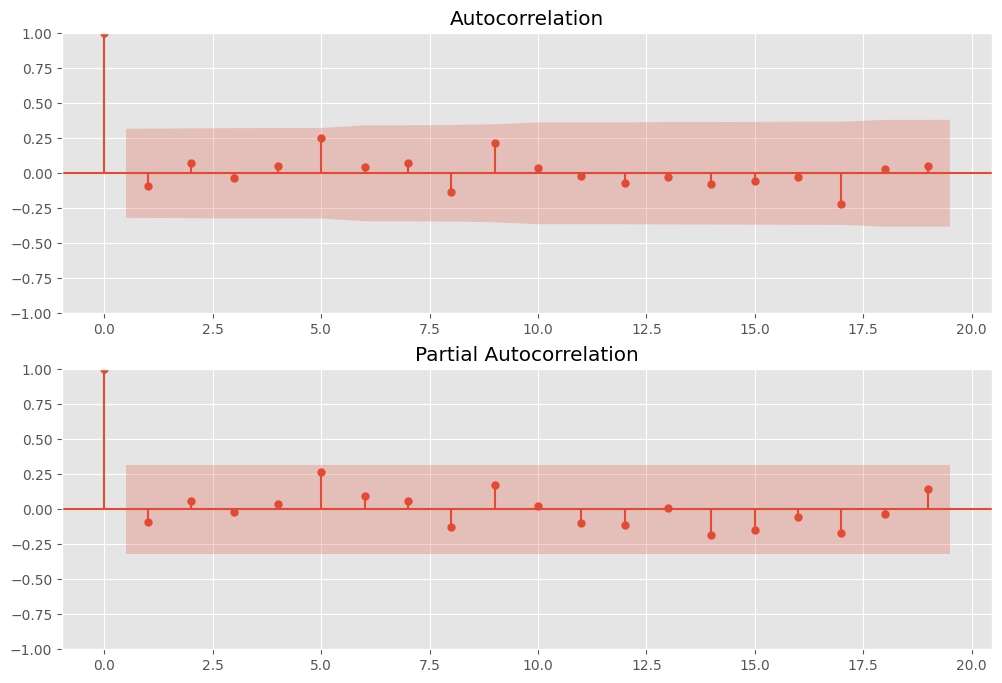

In [302]:
residuals = pd.DataFrame(model_fit.resid)

plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=19, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=19, ax=plt.gca())
plt.show()

Все остатки = Белый шум

In [303]:
df1_fit = model_fit.predict(0, (38+4))
df1_fit

,predicted_mean
0,6059.102261
1,5820.036594
2,6279.157042
3,5904.243617
4,6939.116480
5,5048.546526
6,5047.428424
7,5754.767416
8,6058.821155
9,6332.196984


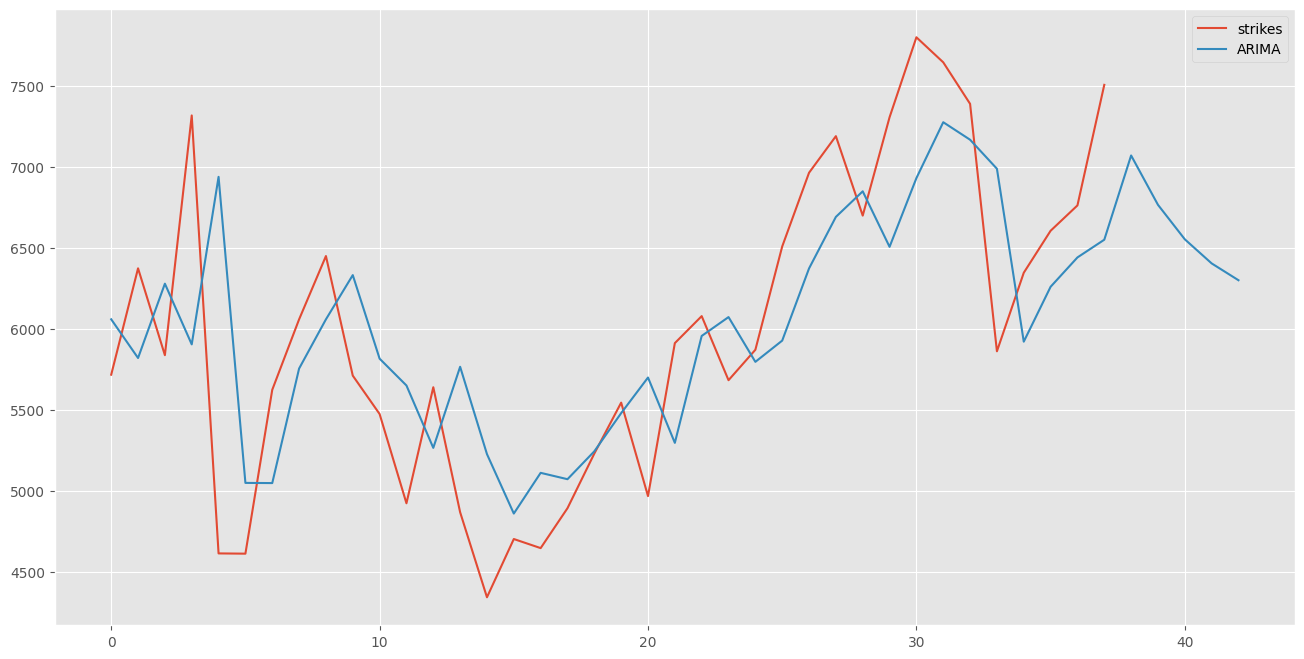

In [304]:
plt.figure(figsize=(16,8))
plt.plot(df1, label='strikes')
plt.plot(df1_fit, label='ARIMA')
plt.legend(loc='best')
plt.show()

## Лабораторная работа по теме ARIMA

https://en.wikipedia.org/wiki/Makridakis_Competitions

В файле с данными по M3 competition
выбрать 3 ряда.

Подобрать модель ARIMA.
Защитить модель перед преподавателем (Аббакумов).
Построить прогноз на 4 наблюдения вперед.

In [305]:
M3C = pd.ExcelFile('M3C.xls')
data = {}
for sheet in 'M3Year M3Quart M3Month M3Other'.split():
    M3Year = M3C.parse(sheet).to_numpy()
    for row in M3Year:
        series = row[0]
        N = row[1]
        data[series] = row[6:6+N]
data

{'N   1': array([940.66, 1084.86, 1244.98, 1445.02, 1683.17, 2038.15, 2342.52,
        2602.45, 2927.87, 3103.96, 3360.27, 3807.63, 4387.88, 4936.99,
        5379.75, 6158.68, 6876.58, 7851.91, 8407.84, 9156.01], dtype=object),
 'N   2': array([1991.05, 2306.4, 2604.0, 2992.3, 3722.08, 5226.62, 5989.46,
        5614.62, 5527.0, 5389.8, 5384.4, 3656.2, 4034.8, 4230.0, 4793.2,
        5602.0, 5065.0, 5056.0, 5067.2, 5209.6], dtype=object),
 'N   3': array([1461.57, 1692.5, 2193.82, 2459.68, 3246.8, 4748.86, 5559.46,
        5292.42, 5029.4, 4753.6, 4344.6, 2897.4, 3256.4, 3525.2, 3070.2,
        3601.6, 3407.4, 3500.6, 3437.8, 3007.0], dtype=object),
 'N   4': array([744.54, 1105.16, 1417.4, 1838.04, 2337.62, 3094.88, 4280.04,
        5070.2, 3675.18, 3667.38, 3808.64, 3114.42, 3847.2, 4632.3, 4656.0,
        5228.52, 5656.72, 5077.02, 5403.4, 5009.52], dtype=object),
 'N   5': array([4977.18, 5248.0, 5370.0, 6184.89, 7137.19, 6743.0, 7298.0, 5260.29,
        4898.18, 5392.04, 5117.64, 4

In [306]:
type(data)

dict

Выберем рандомайзером 3 ряда:

In [307]:
all_series = list(data.keys())
random.seed(22)
random_series = random.sample(all_series, 3)
print(f"Выбраны ряды: {random_series}")

Выбраны ряды: ['N 575', 'N 994', 'N  97']


# N575

In [308]:
df575 = pd.DataFrame(data['N 575'])
df575

,0
0,2561.0
1,2958.0
2,3257.0
3,3627.0
4,4350.0
5,4600.0
6,5072.0
7,5399.0
8,5561.0
9,5707.0


In [309]:
df575.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       25 non-null     object
dtypes: object(1)
memory usage: 332.0+ bytes


<Axes: >

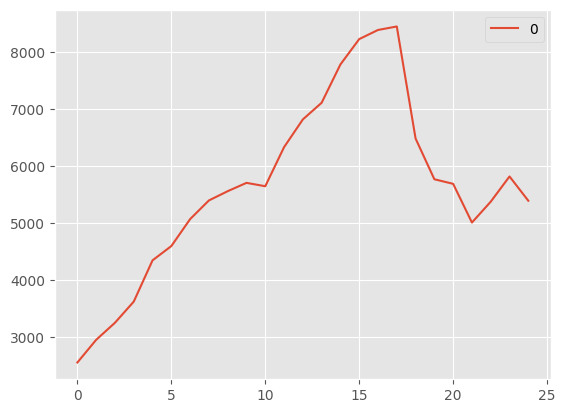

In [310]:
df575[0] = pd.to_numeric(df575[0])
df575.plot()

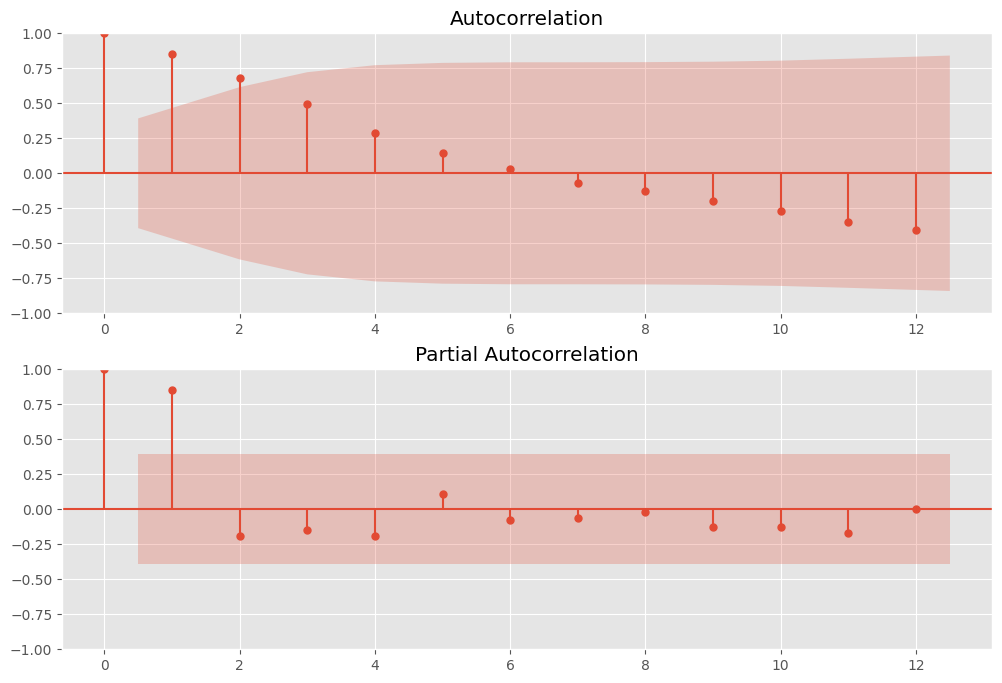

In [311]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df575, lags=12, ax=plt.gca())
plt.subplot(212)

plot_pacf(df575, method='ywmle', lags=12, ax=plt.gca())
plt.show()

Можно увидеть, что автокорреляция экспоненциально убывает, а частичная имеет выброс на лаге 1.

Следовательно, параметры для модели ARIMA должны быть следующие: (1, 0, 0)

In [312]:
model = ARIMA(df575, order=(1,0,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   25
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -195.381
Date:                Wed, 13 May 2026   AIC                            396.762
Time:                        08:44:26   BIC                            400.419
Sample:                             0   HQIC                           397.777
                                 - 25                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4688.6483   1291.345      3.631      0.000    2157.659    7219.638
ar.L1          0.9444      0.065     14.433      0.000       0.816       1.073
sigma2      3.288e+05   1.18e+05      2.777      0.005    9.68e+04    5.61e+05
===================================================================================
Ljung-Box (L1) (Q):                   2.30   Jarque-Bera (JB):                21.72
Prob(Q):                              0.13   Prob(JB):                         0.00
Heteroskedasticity (H):               2.90   Skew:                            -1.70
Prob(H) (two-sided):                  0.15   Kurtosis:                         6.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Можно еще глянуть на разность, чтобы посмотреть улучшится ли модель.

<Axes: >

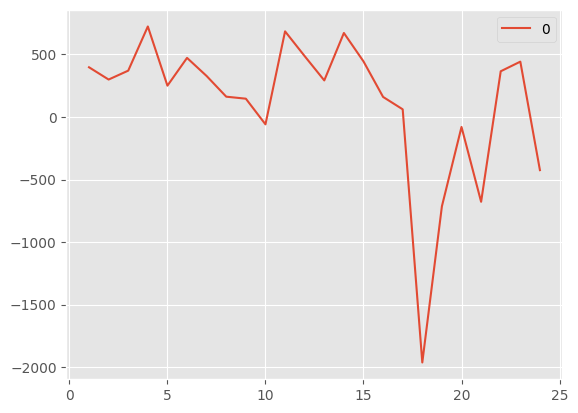

In [313]:
df575_1 = df575.diff().dropna()
df575_1.plot()

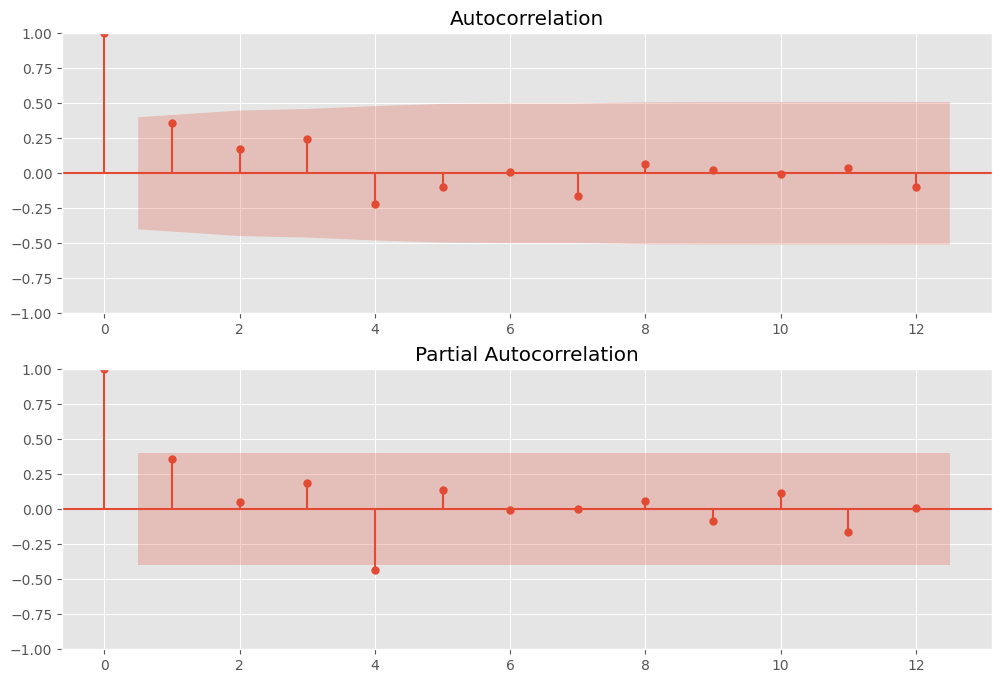

In [314]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df575_1, lags=12, ax=plt.gca())
plt.subplot(212)

plot_pacf(df575_1, method='ywmle', lags=12, ax=plt.gca())
plt.show()

Можно считать, что тут белый шум и модель (0, 1, 0).

Тогда финальную модель будем смотреть (1, 1, 0)

In [315]:
model = ARIMA(df575, order=(1,1,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   25
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -184.718
Date:                Wed, 13 May 2026   AIC                            373.436
Time:                        08:44:30   BIC                            375.792
Sample:                             0   HQIC                           374.061
                                 - 25                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3958      0.433      0.914      0.361      -0.453       1.244
sigma2      2.843e+05   4.35e+04      6.538      0.000    1.99e+05     3.7e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                67.04
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               8.84   Skew:                            -2.34
Prob(H) (two-sided):                  0.01   Kurtosis:                         9.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Если сравнивать все критерии AIC, BIC, HQIC, то для второй модели они улучшились больше, чем на 10, а следовательно модель с разностью будет лучше, поэтому оставим ее.

Анализ остатков:

In [316]:
residuals = pd.DataFrame(model_fit.resid)

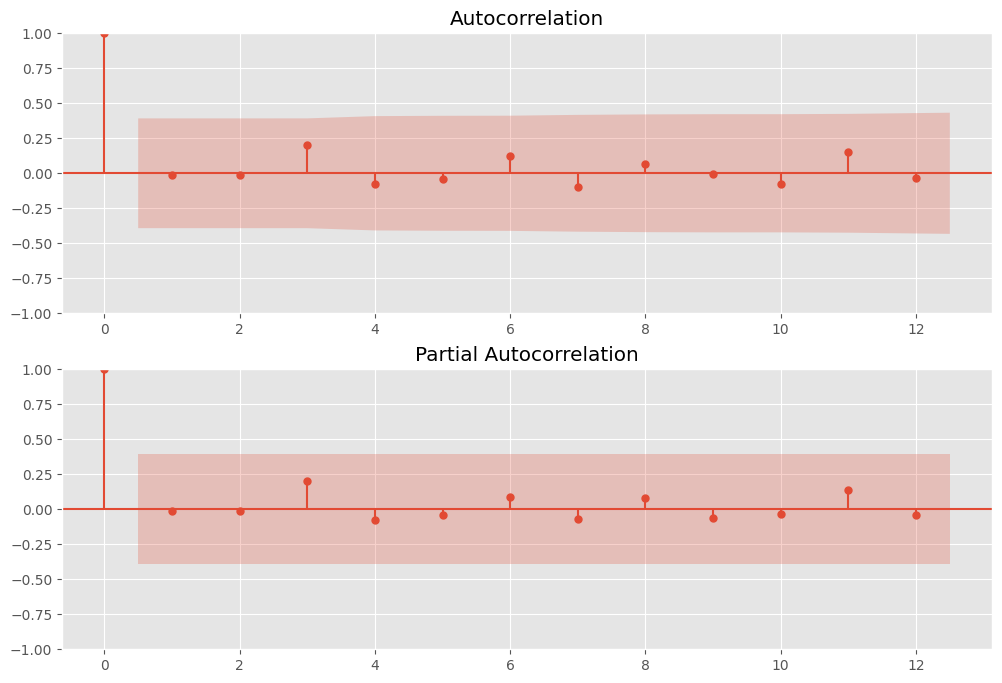

In [317]:
plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=12, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=12, ax=plt.gca())
plt.show()

In [318]:
df575_fit = model_fit.predict(0, (25+4))
df575_fit.tail()

,predicted_mean
25,5225.806178
26,5159.243445
27,5132.901232
28,5122.476297
29,5118.350627


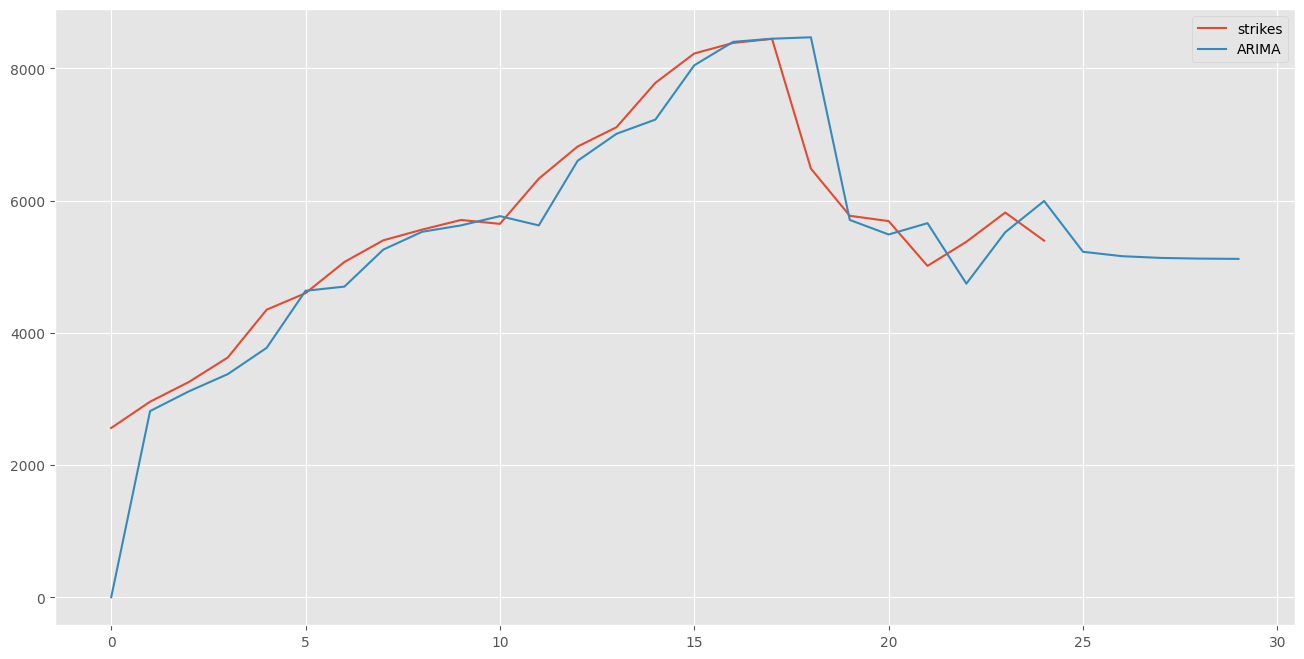

In [319]:
plt.figure(figsize=(16,8))
plt.plot(df575, label='strikes')
plt.plot(df575_fit, label='ARIMA')
plt.legend(loc='best')
plt.show()

# N 994

In [320]:
df994 = pd.DataFrame(data['N 994'])
df994

,0
0,4002.5
1,3819.5
2,4000.0
3,4046.0
4,4045.0
5,4126.5
6,4201.0
7,4269.5
8,4356.5
9,4236.0


In [321]:
df994.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       52 non-null     object
dtypes: object(1)
memory usage: 548.0+ bytes


<Axes: >

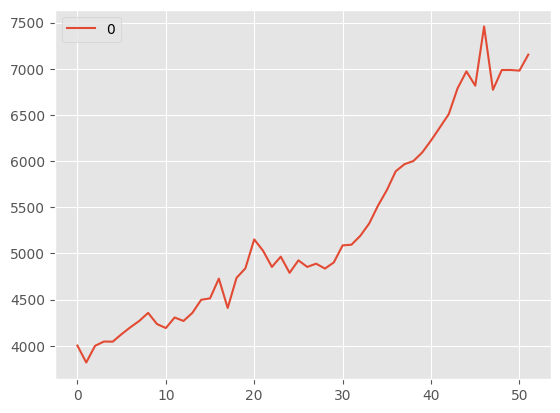

In [322]:
df994[0] = pd.to_numeric(df994[0])
df994.plot()

Лучше сразу посмотреть с разницей, так как ряд имеет определенный тренд и не является стационарным.

<Axes: >

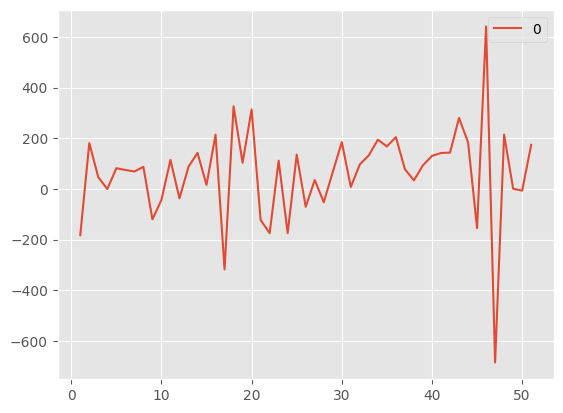

In [323]:
df994_1 = df994.diff().dropna()
df994_1.plot()

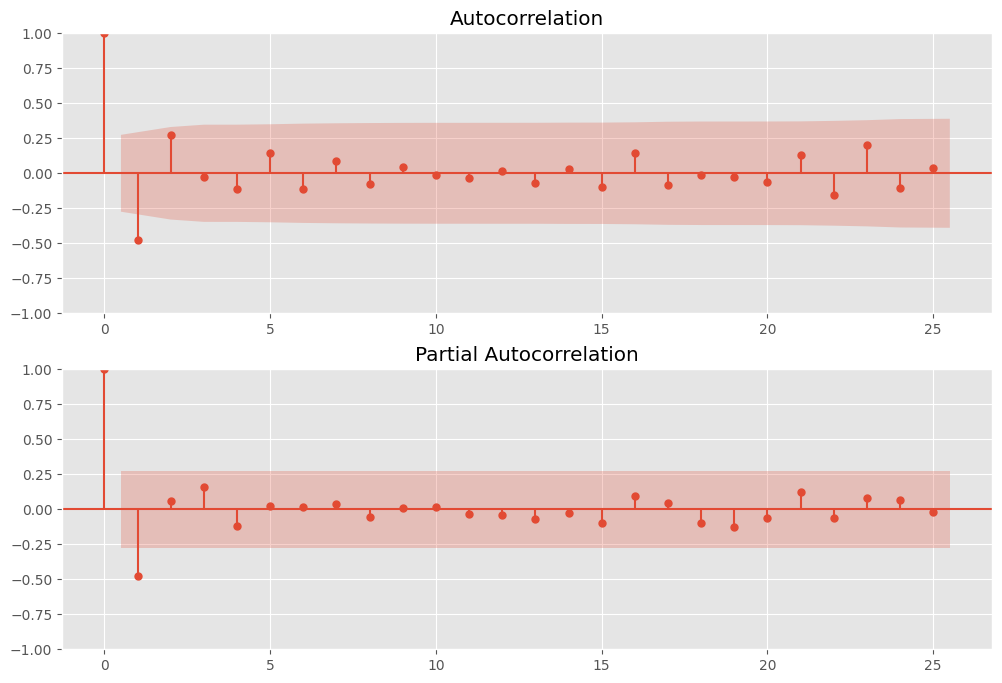

In [324]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df994_1, lags=25, ax=plt.gca())
plt.subplot(212)

plot_pacf(df994_1, method='ywmle', lags=25, ax=plt.gca())
plt.show()

Тут нельзя сказать, где выброс, а где экспоненциальное убывание, поэтому посмотрим на обе модели и сравним

In [325]:
model = ARIMA(df994, order=(1,1,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   52
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -338.550
Date:                Wed, 13 May 2026   AIC                            681.101
Time:                        08:44:42   BIC                            684.964
Sample:                             0   HQIC                           682.577
                                 - 52                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3391      0.108     -3.139      0.002      -0.551      -0.127
sigma2      3.444e+04   6482.183      5.313      0.000    2.17e+04    4.71e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):                11.64
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               4.17   Skew:                            -0.32
Prob(H) (two-sided):                  0.01   Kurtosis:                         5.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [326]:
model1 = ARIMA(df994, order=(0,1,1))
model1_fit = model.fit()
model1_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   52
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -338.550
Date:                Wed, 13 May 2026   AIC                            681.101
Time:                        08:44:44   BIC                            684.964
Sample:                             0   HQIC                           682.577
                                 - 52                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3391      0.108     -3.139      0.002      -0.551      -0.127
sigma2      3.444e+04   6482.183      5.313      0.000    2.17e+04    4.71e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):                11.64
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               4.17   Skew:                            -0.32
Prob(H) (two-sided):                  0.01   Kurtosis:                         5.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Разница между двумя моделями незначительная, поэтому возьмем (1,1,0), так как при построении автокорреляций без разницы выброс был на частной автокорреляции.

Анализ остатков:

In [327]:
residuals = pd.DataFrame(model_fit.resid)

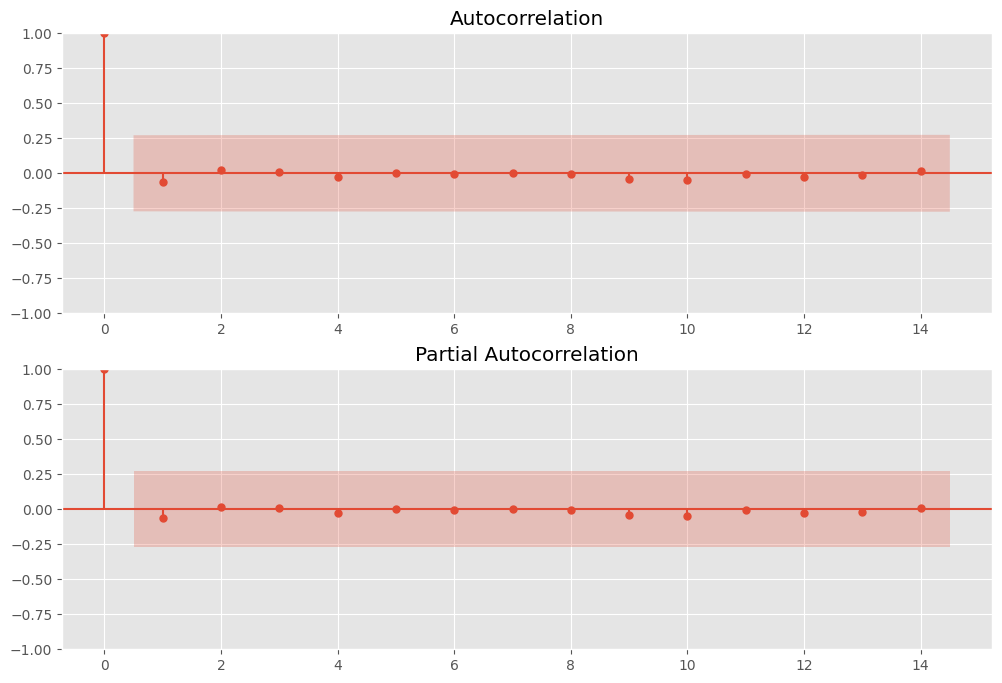

In [328]:
plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=14, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=14, ax=plt.gca())
plt.show()


Перейдем к предсказанию

In [329]:
df994_fit = model_fit.predict(0, (52+4))
df994_fit.tail()

,predicted_mean
52,7093.664063
53,7113.616037
54,7106.850083
55,7109.144499
56,7108.366435


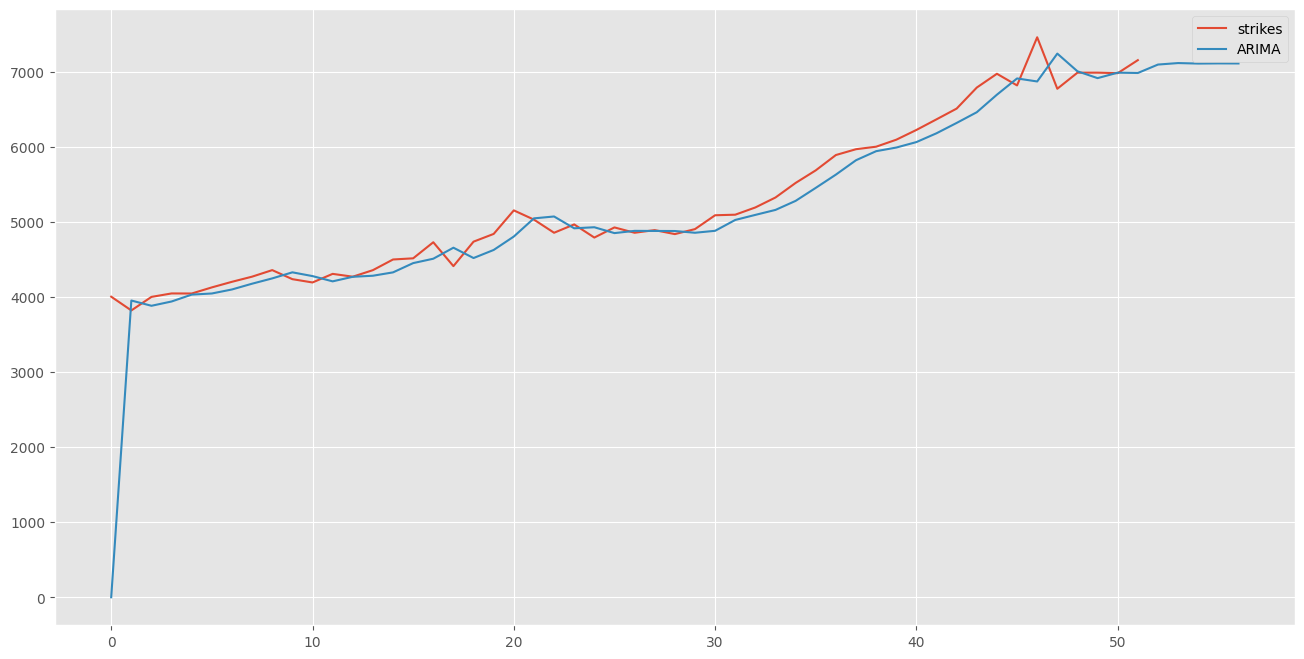

In [330]:
plt.figure(figsize=(16,8))
plt.plot(df994, label='strikes')
plt.plot(df994_fit, label='ARIMA')
plt.legend(loc='best')
plt.show()

# N  97

In [331]:
df97 = pd.DataFrame(data['N  97'])
df97

,0
0,1393.7
1,1618.91
2,2077.06
3,2256.05
4,2638.11
5,3048.69
6,3625.17
7,3910.42
8,4299.06
9,3852.6


In [332]:
df97.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       20 non-null     object
dtypes: object(1)
memory usage: 292.0+ bytes


<Axes: >

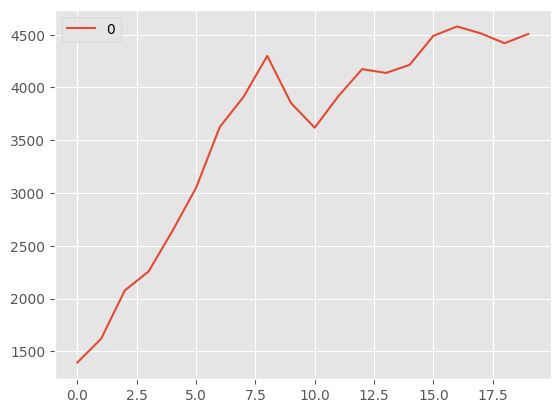

In [333]:
df97[0] = pd.to_numeric(df97[0])
df97.plot()

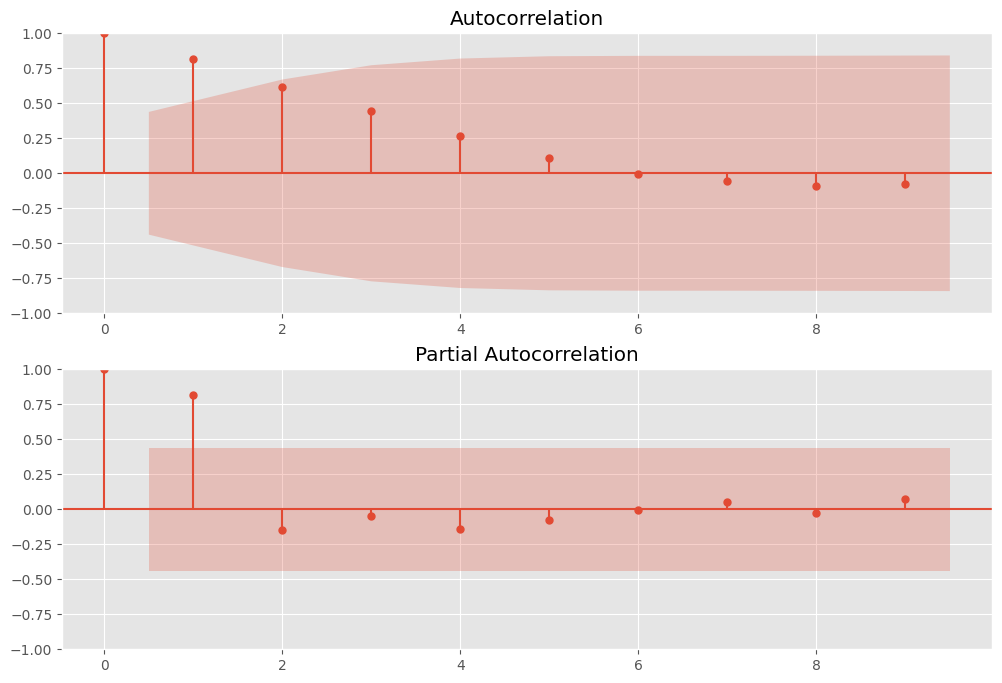

In [334]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df97, lags=9, ax=plt.gca())
plt.subplot(212)

plot_pacf(df97, method='ywmle', lags=9, ax=plt.gca())
plt.show()

Где именно тут выброс, а где экспоненциальное убывание сказать сложно, поэтому будем сравнивать оба варианта модели.

Также данные не выглядят стационарными, у них есть определенный возрастающий тренд, будем смотреть с разностью тоже.

<Axes: >

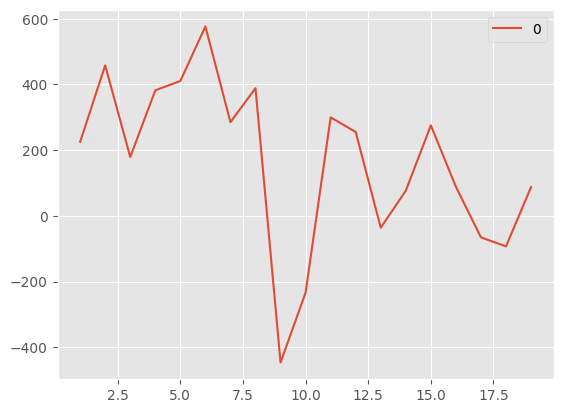

In [335]:
df97_1 = df97.diff().dropna()
df97_1.plot()

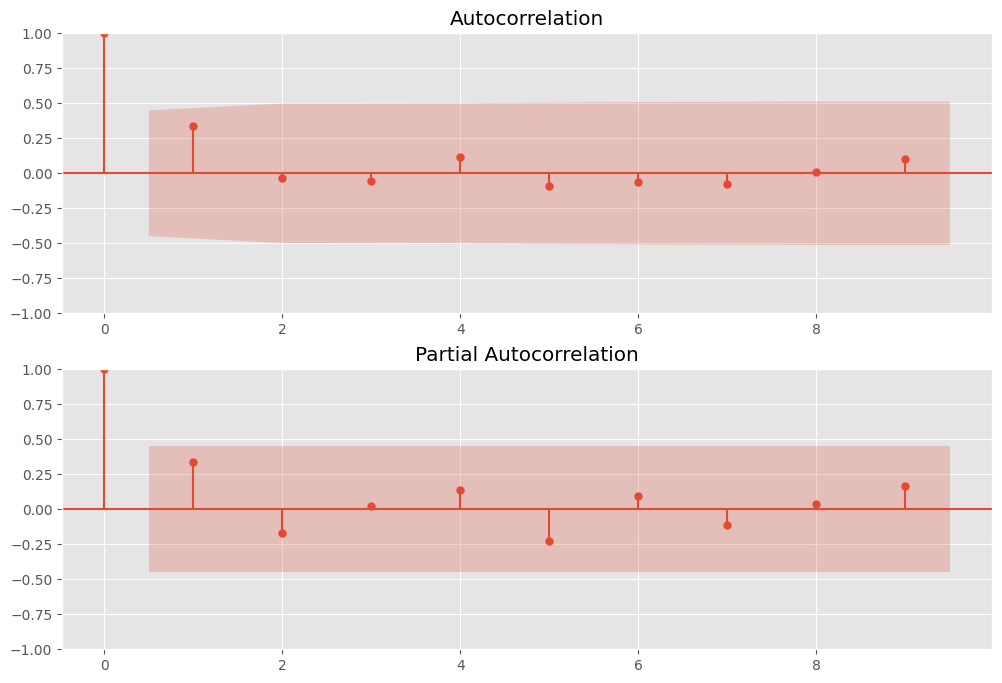

In [336]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df97_1, lags=9, ax=plt.gca())
plt.subplot(212)

plot_pacf(df97_1, method='ywmle', lags=9, ax=plt.gca())
plt.show()

Можно сказать, что это случайное блуждание ARIMA (0,1,0)

Тогда посмотрим два варианта модели (1,1,0) и (0,1,1) и выберем лучший из них

In [337]:
model = ARIMA(df222, order=(1,1,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   20
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -132.093
Date:                Wed, 13 May 2026   AIC                            268.186
Time:                        08:44:56   BIC                            270.075
Sample:                             0   HQIC                           268.506
                                 - 20                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5225      0.225      2.322      0.020       0.081       0.964
sigma2      6.375e+04   2.33e+04      2.733      0.006     1.8e+04    1.09e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 7.77
Prob(Q):                              0.70   Prob(JB):                         0.02
Heteroskedasticity (H):               0.26   Skew:                            -1.19
Prob(H) (two-sided):                  0.12   Kurtosis:                         5.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [338]:
model1 = ARIMA(df222, order=(0,1,1))
model1_fit = model.fit()
model1_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      0   No. Observations:                   20
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -132.093
Date:                Wed, 13 May 2026   AIC                            268.186
Time:                        08:44:57   BIC                            270.075
Sample:                             0   HQIC                           268.506
                                 - 20                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5225      0.225      2.322      0.020       0.081       0.964
sigma2      6.375e+04   2.33e+04      2.733      0.006     1.8e+04    1.09e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 7.77
Prob(Q):                              0.70   Prob(JB):                         0.02
Heteroskedasticity (H):               0.26   Skew:                            -1.19
Prob(H) (two-sided):                  0.12   Kurtosis:                         5.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Разница между двумя этими моделями вообще незначительная, поэтому просто выберем ту, которая чуть лучше.

Анализ остатков:

In [339]:
residuals = pd.DataFrame(model_fit.resid)

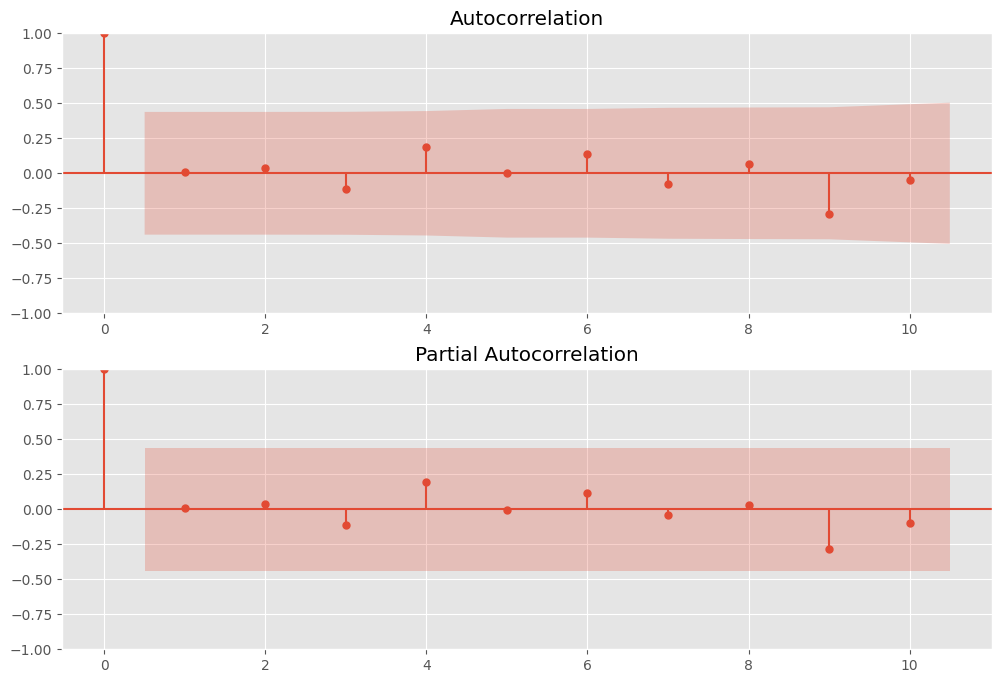

In [340]:
plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=10, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=10, ax=plt.gca())
plt.show()


Перейдем к предсказанию

In [341]:
df97_fit = model_fit.predict(0, (20+4))
df97_fit.tail()

,predicted_mean
20,4552.772296
21,4576.688997
22,4589.185828
23,4595.715606
24,4599.127512


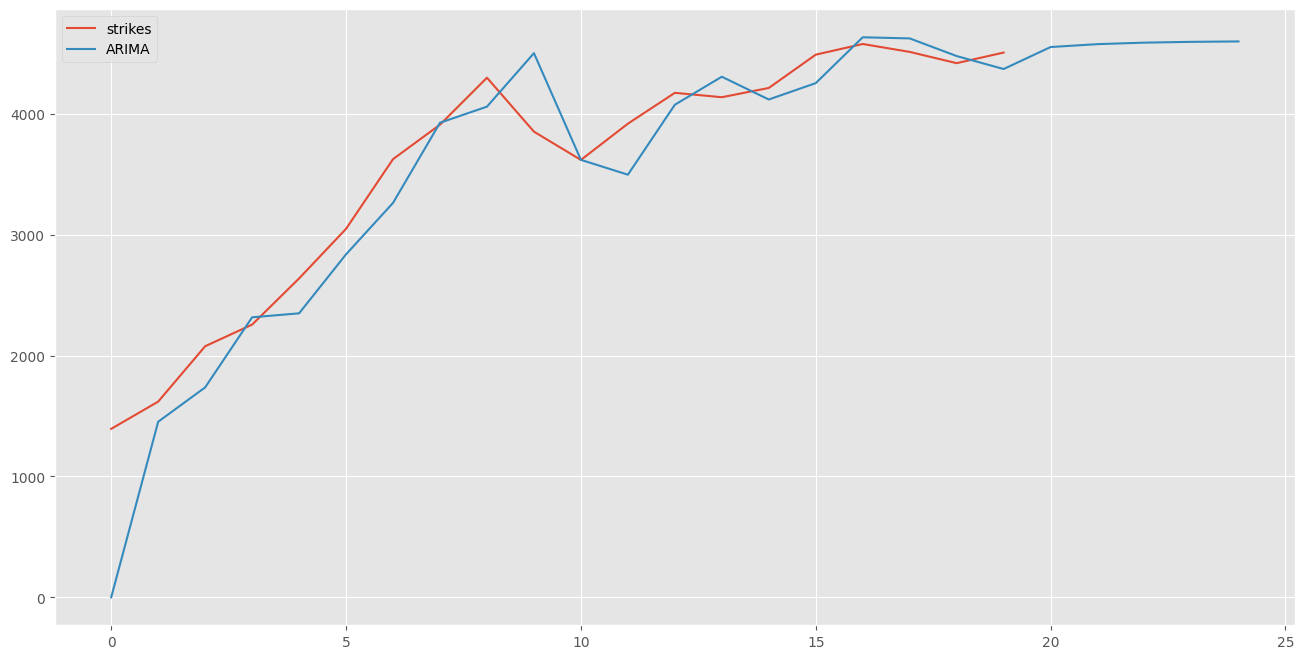

In [342]:
plt.figure(figsize=(16,8))
plt.plot(df97, label='strikes')
plt.plot(df97_fit, label='ARIMA')
plt.legend(loc='best')
plt.show()